# importing libraries

In [63]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import chi2 , f_classif
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import MinMaxScaler,StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression,SGDClassifier
from sklearn.naive_bayes import GaussianNB,MultinomialNB,BernoulliNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis,QuadraticDiscriminantAnalysis
from sklearn.svm import SVC
from catboost import CatBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report,precision_score, recall_score, f1_score,confusion_matrix
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV
import pandas as pd
from catboost import CatBoostClassifier
from sklearn.model_selection import RandomizedSearchCV
from sqlalchemy import create_engine
import urllib

# Loading Data from SQL 

In [2]:
file_name = "reordered_classification_dataset_sample.csv"

if os.path.exists(file_name):
    print("CSV file found. Loading from disk...")
    df = pd.read_csv(file_name)

else:
    print("CSV file not found. Loading from SQL Server...")

    params = urllib.parse.quote_plus(
        "DRIVER={ODBC Driver 17 for SQL Server};"
        "SERVER=localhost\\SQLEXPRESS;"
        "DATABASE=Instacart;"
        "Trusted_Connection=yes;"
        "TrustServerCertificate=yes;"
    )

    engine = create_engine(f"mssql+pyodbc:///?odbc_connect={params}")

    query = """
    SELECT *
    FROM reordered_classification_dataset_sample
    """

    df = pd.read_sql(query, engine)

    df.to_csv(file_name, index=False)

    print(f"Dataset saved as '{file_name}'")

print(df.shape)
display(df.head())

CSV file found. Loading from disk...
(443544, 19)


,user_id,order_id,order_number,order_dow,order_hour_of_day,days_since_prior_order,product_id,product_name,department,aisle,add_to_cart_order,total_orders_for_user,user_reorder_rate,average_basket_size,product_popularity,product_reorder_rate,department_reorder_rate,aisle_reorder_rate,reordered
0,75564,203,11,4,14,8.0,26348,Mixed Fruit Fruit Snacks,snacks,fruit vegetable snacks,1,26,0.7361,3,9955,0.6907,0.5742,0.5924,1
1,5927,289,14,0,8,7.0,920,Coconut Yogurt,dairy eggs,yogurt,12,61,0.7635,15,3157,0.6199,0.6700,0.6865,1
2,5927,289,14,0,8,7.0,1234,Cream Top Smooth & Creamy Plain Yogurt,dairy eggs,yogurt,2,61,0.7635,15,3465,0.7307,0.6700,0.6865,1
3,5927,289,14,0,8,7.0,2664,First Prunes,babies,baby food formula,6,61,0.7635,15,2962,0.5729,0.5790,0.5903,1
4,5927,289,14,0,8,7.0,4001,Probugs Strawnana Split Frozen Ypgurt,frozen,ice cream ice,18,61,0.7635,15,866,0.5774,0.5419,0.4924,0


# Data preprocessing

In [3]:
df.describe()

,user_id,order_id,order_number,order_dow,order_hour_of_day,days_since_prior_order,product_id,add_to_cart_order,total_orders_for_user,user_reorder_rate,average_basket_size,product_popularity,product_reorder_rate,department_reorder_rate,aisle_reorder_rate,reordered
count,443544.000000,4.435440e+05,443544.000000,443544.000000,443544.000000,443544.000000,443544.000000,443544.000000,443544.000000,443544.000000,443544.000000,443544.000000,443544.000000,443544.000000,443544.000000,443544.000000
mean,103088.596493,1.710463e+06,17.991669,2.761374,13.384963,11.154057,25588.118604,8.342469,33.924458,0.598646,15.222850,36241.032121,0.591381,0.590267,0.590468,0.631847
std,59469.403988,9.901941e+05,17.336834,2.086756,4.241400,8.774533,14094.218495,7.105609,25.109292,0.184847,7.315179,80208.004389,0.149808,0.097025,0.114733,0.482304
min,2.000000,1.210000e+02,2.000000,0.000000,0.000000,0.000000,1.000000,1.000000,3.000000,0.000000,1.000000,1.000000,0.000000,0.321100,0.152400,0.000000
25%,51599.000000,8.553880e+05,6.000000,1.000000,10.000000,5.000000,13517.000000,3.000000,14.000000,0.480800,10.000000,1683.000000,0.510900,0.560900,0.541500,0.000000
50%,102802.000000,1.710178e+06,12.000000,3.000000,13.000000,8.000000,25256.000000,6.000000,27.000000,0.630200,14.000000,6891.000000,0.612700,0.649900,0.594500,1.000000
75%,154331.000000,2.574144e+06,25.000000,5.000000,16.000000,15.000000,38000.000000,11.000000,48.000000,0.742700,19.000000,29069.000000,0.695800,0.653500,0.686500,1.000000
max,206207.000000,3.421069e+06,99.000000,6.000000,23.000000,30.000000,49688.000000,88.000000,99.000000,0.989500,74.000000,472565.000000,0.941200,0.670000,0.781400,1.000000


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 443544 entries, 0 to 443543
Data columns (total 19 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   user_id                  443544 non-null  int64  
 1   order_id                 443544 non-null  int64  
 2   order_number             443544 non-null  int64  
 3   order_dow                443544 non-null  int64  
 4   order_hour_of_day        443544 non-null  int64  
 5   days_since_prior_order   443544 non-null  float64
 6   product_id               443544 non-null  int64  
 7   product_name             443544 non-null  object 
 8   department               443544 non-null  object 
 9   aisle                    443544 non-null  object 
 10  add_to_cart_order        443544 non-null  int64  
 11  total_orders_for_user    443544 non-null  int64  
 12  user_reorder_rate        443544 non-null  float64
 13  average_basket_size      443544 non-null  int64  
 14  prod

In [5]:
df.isnull().sum()

user_id                    0
order_id                   0
order_number               0
order_dow                  0
order_hour_of_day          0
days_since_prior_order     0
product_id                 0
product_name               0
department                 0
aisle                      0
add_to_cart_order          0
total_orders_for_user      0
user_reorder_rate          0
average_basket_size        0
product_popularity         0
product_reorder_rate       0
department_reorder_rate    0
aisle_reorder_rate         0
reordered                  0
dtype: int64

In [6]:
df["user_id"].nunique()

35732

# EDA

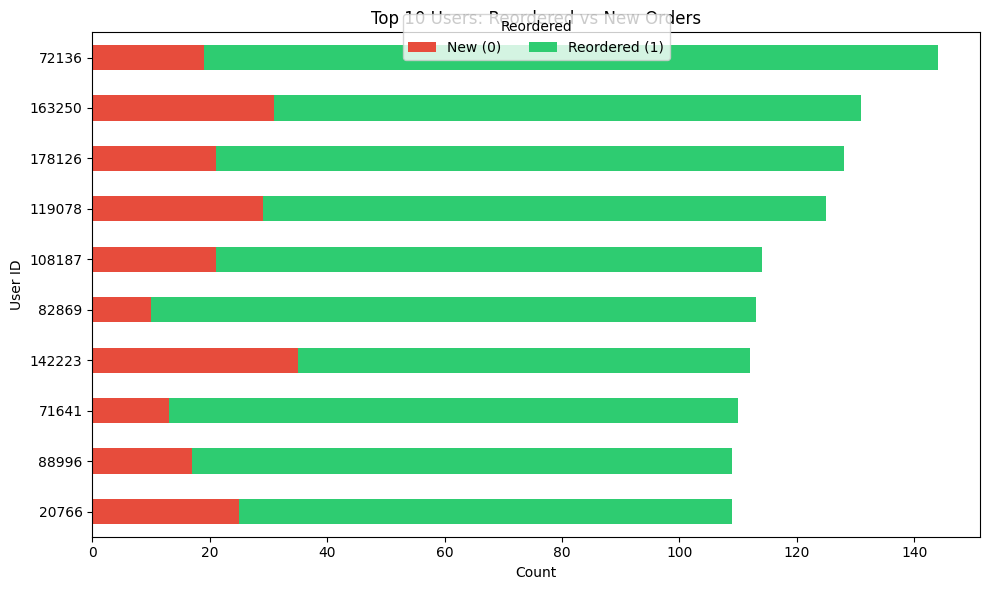

In [7]:
top10_users = df["user_id"].value_counts().head(10).index
user_reorder = df[df["user_id"].isin(top10_users)].groupby(["user_id", "reordered"]).size().reset_index(name="Count")

pivot = user_reorder.pivot_table(index="user_id", columns="reordered", values="Count", fill_value=0)
pivot["total"] = pivot.sum(axis=1)
pivot = pivot.sort_values("total", ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
pivot[0].plot(kind="barh", ax=ax, color="#E74C3C", label="New (0)")
pivot[1].plot(kind="barh", ax=ax, left=pivot[0], color="#2ECC71", label="Reordered (1)")

ax.set_xlabel("Count")
ax.set_ylabel("User ID")
ax.set_title("Top 10 Users: Reordered vs New Orders")
ax.legend(title="Reordered", loc="upper center", bbox_to_anchor=(0.5, 1.05), ncol=2)
plt.tight_layout()
plt.show()

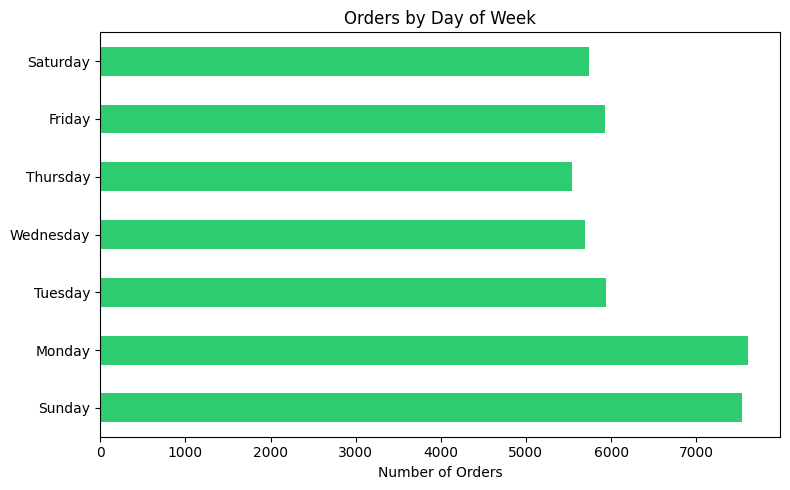

In [8]:
orders = df.drop_duplicates(subset="order_id")

day_names = {0: "Sunday", 1: "Monday", 2: "Tuesday", 3: "Wednesday",
             4: "Thursday", 5: "Friday", 6: "Saturday"}

dow_counts = orders["order_dow"].value_counts().sort_index()
dow_counts.index = dow_counts.index.map(day_names)

plt.figure(figsize=(8, 5))
dow_counts.plot(kind="barh", color="#2ECC71")
plt.title("Orders by Day of Week")
plt.xlabel("Number of Orders")
plt.ylabel("")
plt.tight_layout()
plt.show()

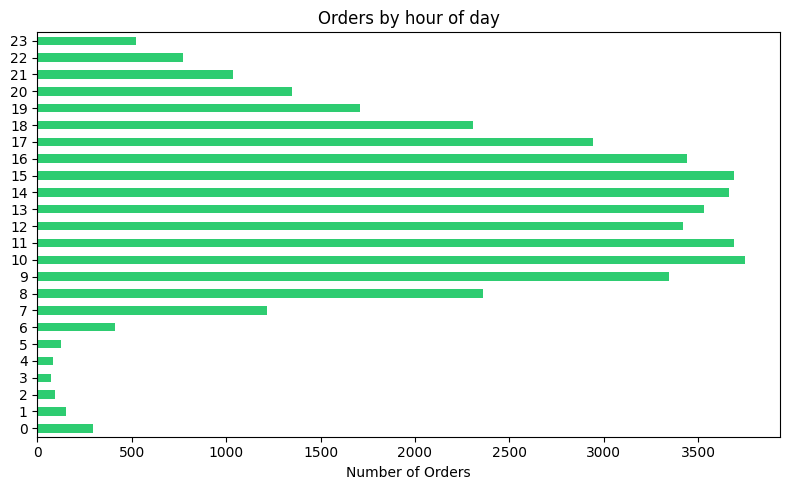

In [9]:
orders = df.drop_duplicates(subset="order_id")



dow_counts = orders["order_hour_of_day"].value_counts().sort_index()


plt.figure(figsize=(8, 5))
dow_counts.plot(kind="barh", color="#2ECC71")
plt.title("Orders by hour of day")
plt.xlabel("Number of Orders")
plt.ylabel("")
plt.tight_layout()
plt.show()

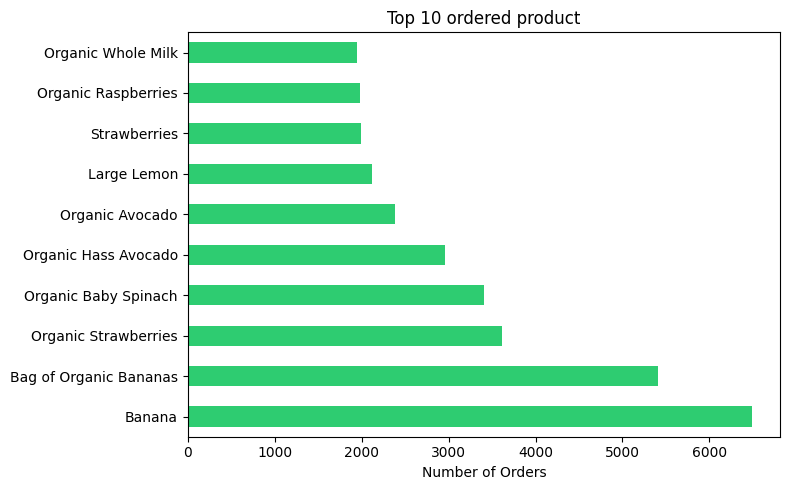

In [10]:
prod_counts = df["product_name"].value_counts().sort_values(ascending=False).head(10)
plt.figure(figsize=(8, 5))
prod_counts.plot(kind="barh", color="#2ECC71")
plt.title("Top 10 ordered product")
plt.xlabel("Number of Orders")
plt.ylabel("")
plt.tight_layout()
plt.show()

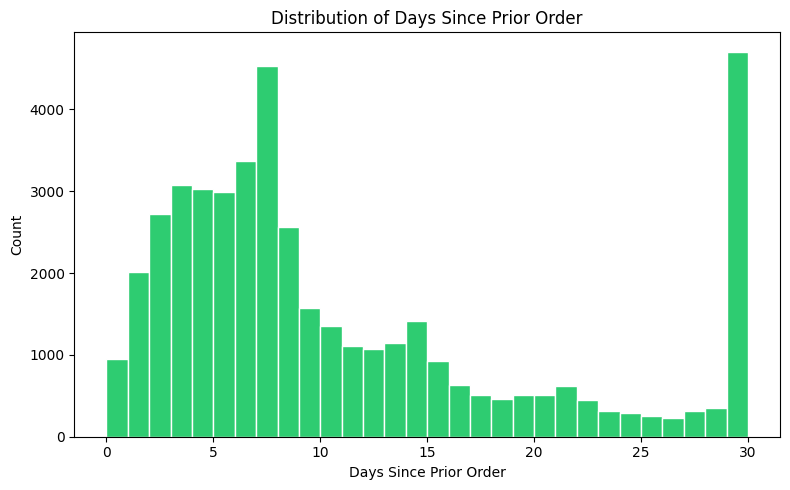

In [11]:
plt.figure(figsize=(8, 5))
plt.hist(orders["days_since_prior_order"], bins=30, color="#2ECC71", edgecolor="white")
plt.title("Distribution of Days Since Prior Order")
plt.xlabel("Days Since Prior Order")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

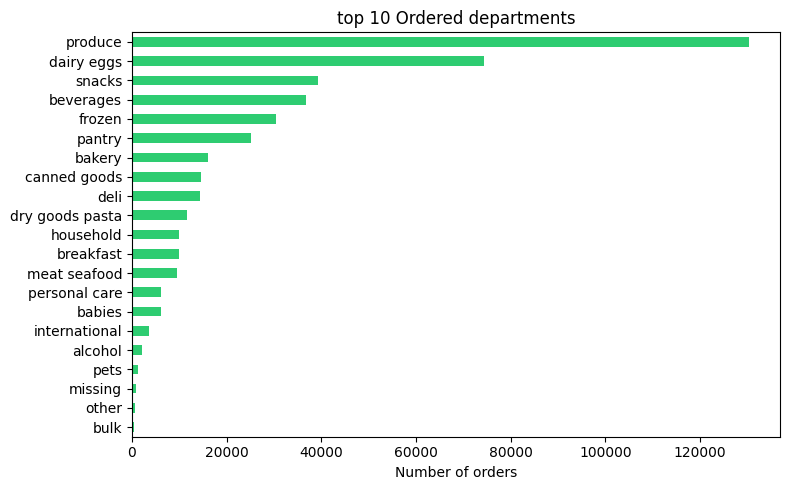

In [12]:
prod_counts = df["department"].value_counts().sort_values()
plt.figure(figsize=(8, 5))
prod_counts.plot(kind="barh", color="#2ECC71")
plt.title("top 10 Ordered departments")
plt.xlabel("Number of orders")
plt.ylabel("")
plt.tight_layout()
plt.show()

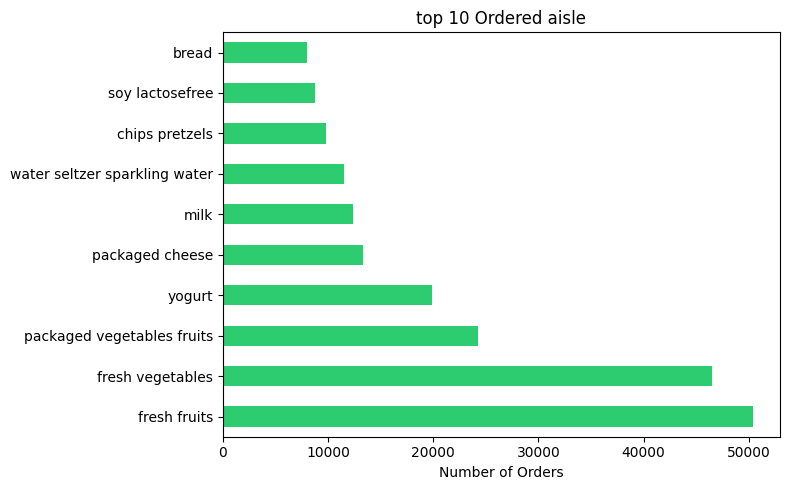

In [13]:
prod_counts = df["aisle"].value_counts().sort_values(ascending=False).head(10)
plt.figure(figsize=(8, 5))
prod_counts.plot(kind="barh", color="#2ECC71")
plt.title("top 10 Ordered aisle")
plt.xlabel("Number of Orders")
plt.ylabel("")
plt.tight_layout()
plt.show()

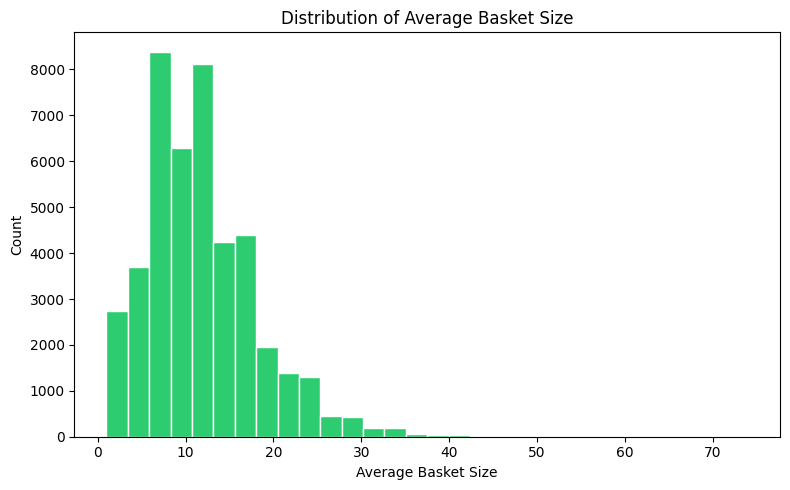

In [14]:
plt.figure(figsize=(8, 5))
plt.hist(orders["average_basket_size"], bins=30, color="#2ECC71", edgecolor="white")
plt.title("Distribution of Average Basket Size")
plt.xlabel("Average Basket Size")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

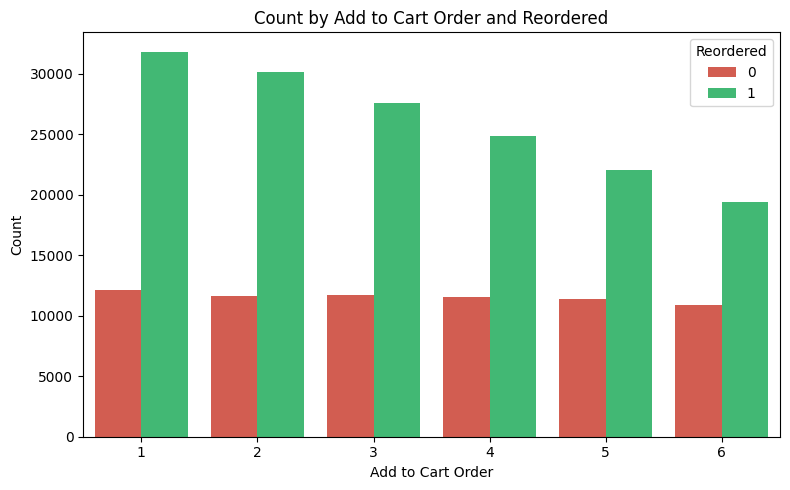

In [15]:
orders = df[df["add_to_cart_order"] <= 6]

plt.figure(figsize=(8, 5))
sns.countplot(
    data=orders,
    x="add_to_cart_order",
    hue="reordered",
    palette={0: "#E74C3C", 1: "#2ECC71"},
)
plt.title("Count by Add to Cart Order and Reordered")
plt.xlabel("Add to Cart Order")
plt.ylabel("Count")
plt.legend(title="Reordered")
plt.tight_layout()
plt.show()

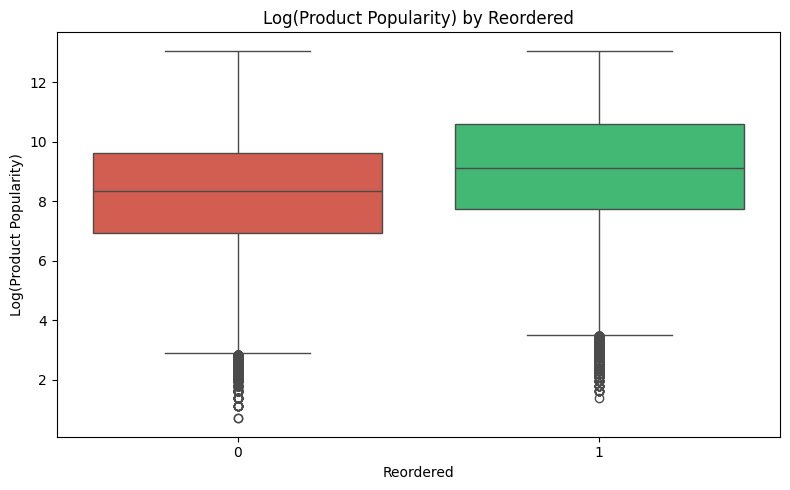

In [16]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="reordered",
    y=np.log1p(df["product_popularity"]),
    hue="reordered",
    palette={0:"#E74C3C",1:"#2ECC71"},
    legend=False
)

plt.title("Log(Product Popularity) by Reordered")
plt.xlabel("Reordered")
plt.ylabel("Log(Product Popularity)")
plt.tight_layout()
plt.show()

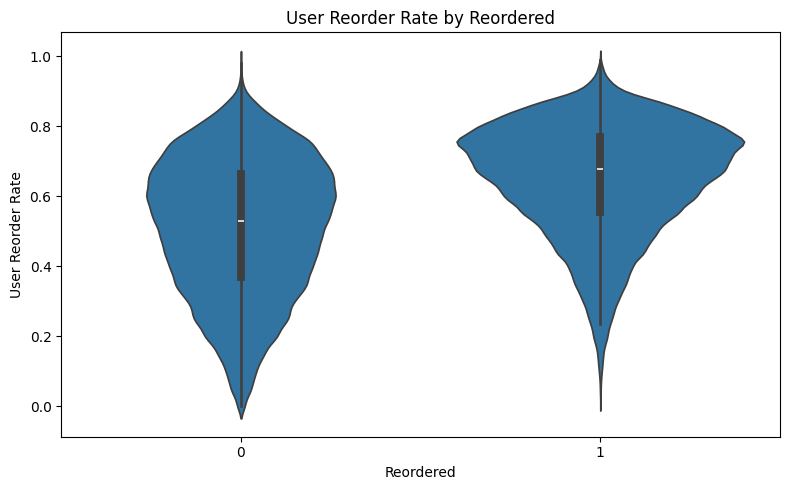

In [17]:
plt.figure(figsize=(8, 5))
sns.violinplot(
    data=df,
    x="reordered",
    y="user_reorder_rate",
    # palette={0: "#E74C3C", 1: "#2ECC71"},
    inner="box",
)
plt.title("User Reorder Rate by Reordered")
plt.xlabel("Reordered")
plt.ylabel("User Reorder Rate")
plt.tight_layout()
plt.show()

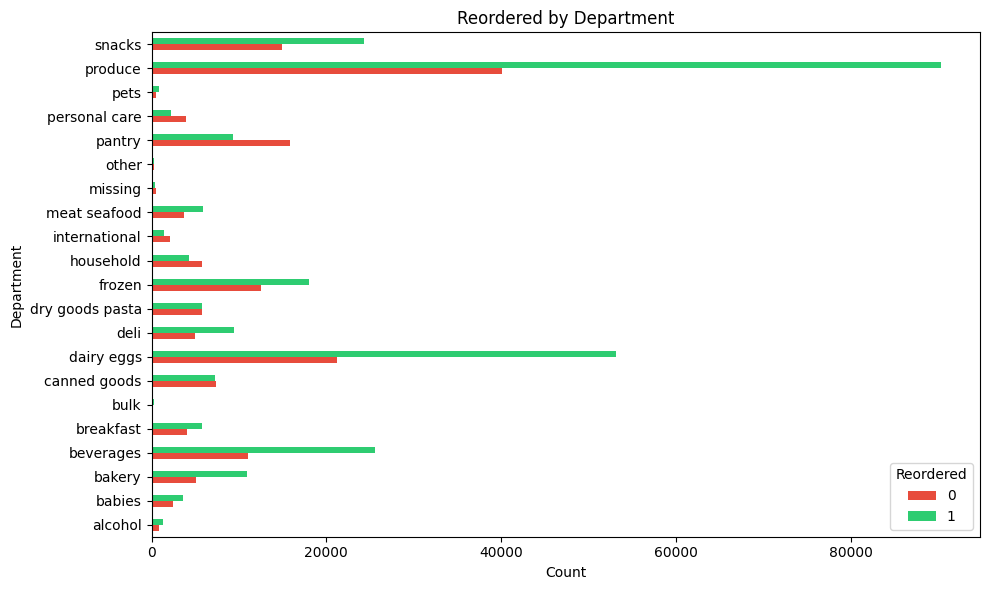

In [18]:
ct = pd.crosstab(df["department"], df["reordered"])
ct.plot(kind="barh", figsize=(10, 6), color=["#E74C3C", "#2ECC71"])
plt.title("Reordered by Department")
plt.xlabel("Count")
plt.ylabel("Department")
plt.legend(title="Reordered")
plt.tight_layout()
plt.show()

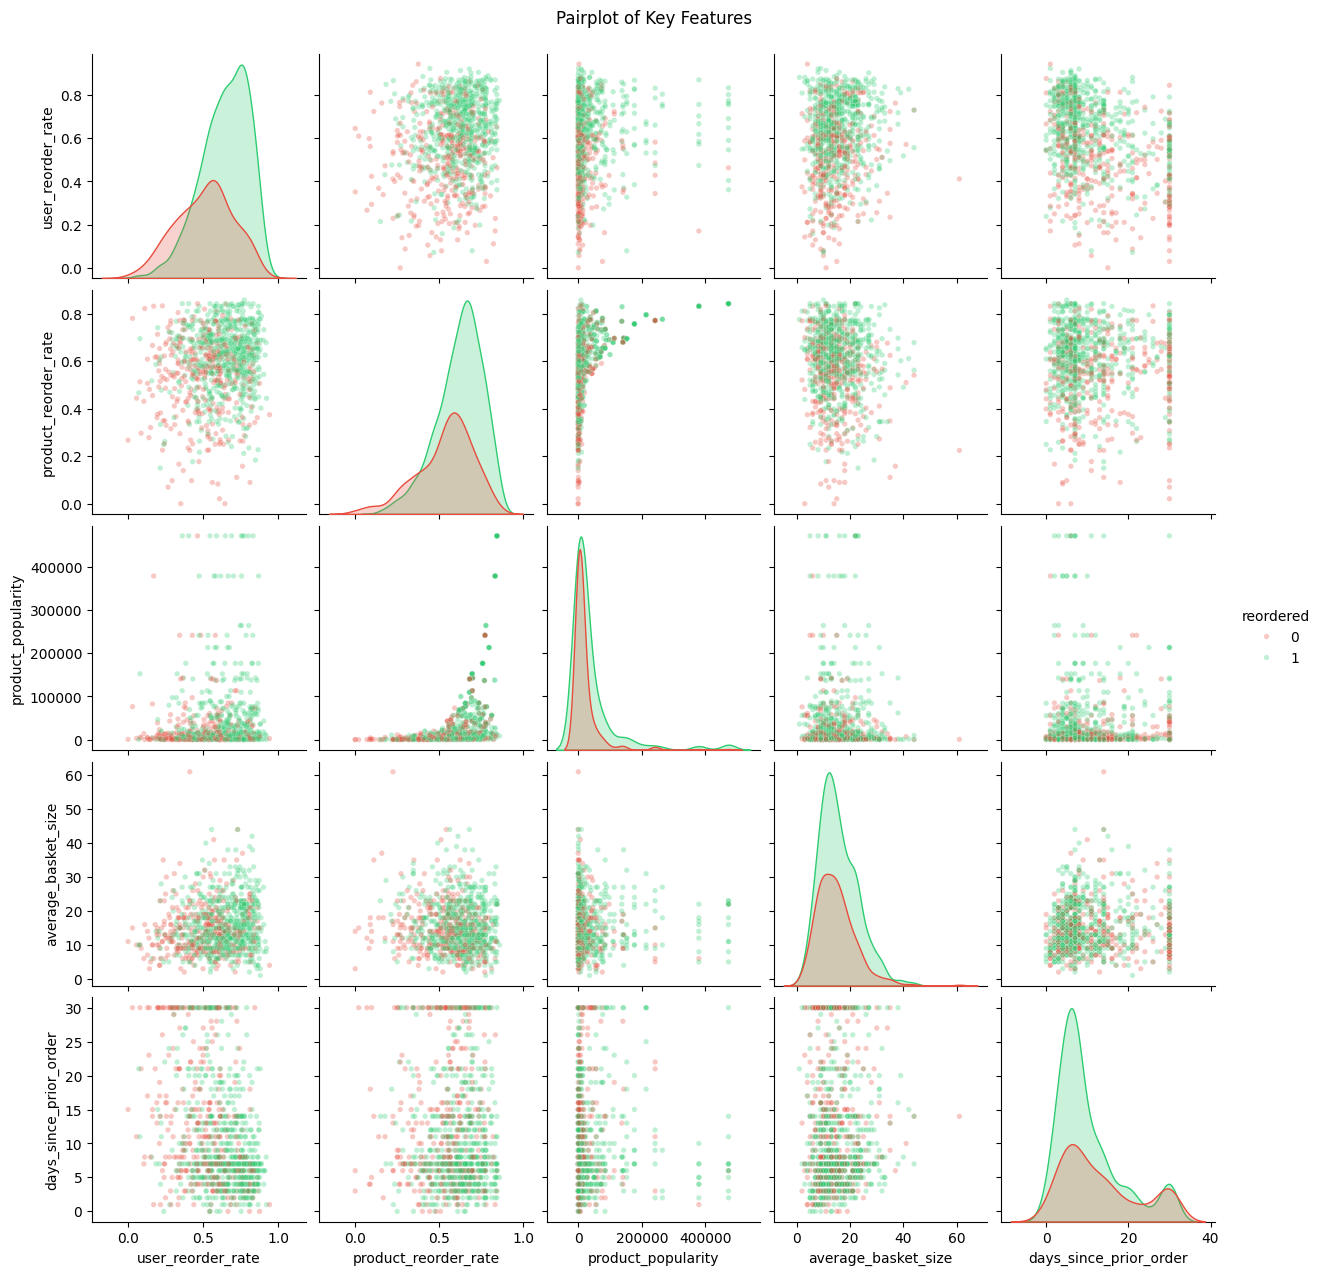

In [19]:
cols = ["user_reorder_rate", "product_reorder_rate", "product_popularity",
        "average_basket_size", "days_since_prior_order", "reordered"]

sns.pairplot(
    df[cols].sample(1000, random_state=42),
    hue="reordered",
    palette={0: "#E74C3C", 1: "#2ECC71"},
    diag_kind="kde",
    plot_kws={"alpha": 0.3, "s": 15},
)
plt.suptitle("Pairplot of Key Features", y=1.02)
plt.show()

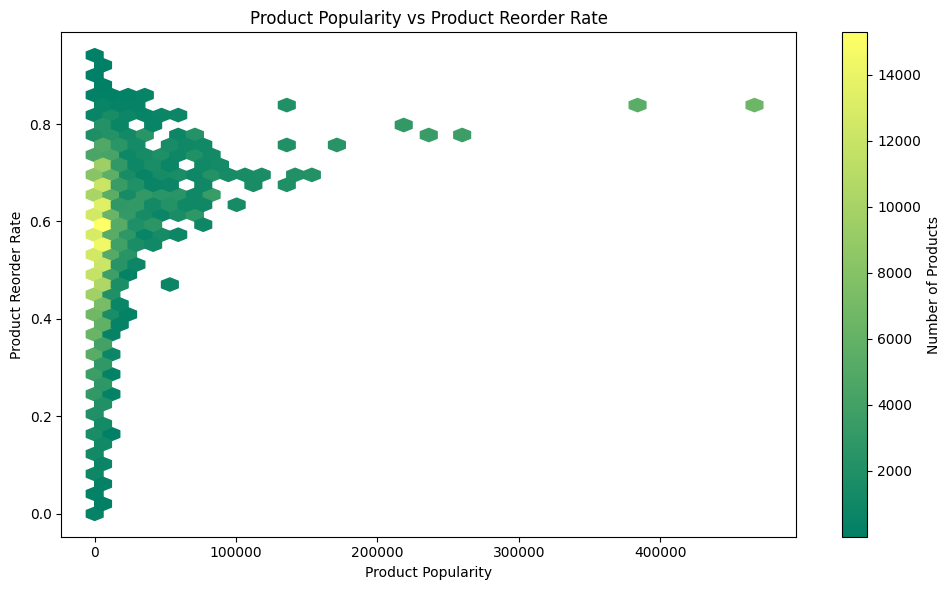

In [ ]:
plt.figure(figsize=(10,6))

hb = plt.hexbin(
    df["product_popularity"],
    df["product_reorder_rate"],
    gridsize=40,
    cmap="summer",     
    mincnt=1
)

plt.colorbar(hb, label="Number of Products")

plt.title("Product Popularity vs Product Reorder Rate")
plt.xlabel("Product Popularity")
plt.ylabel("Product Reorder Rate")

plt.tight_layout()
plt.show()

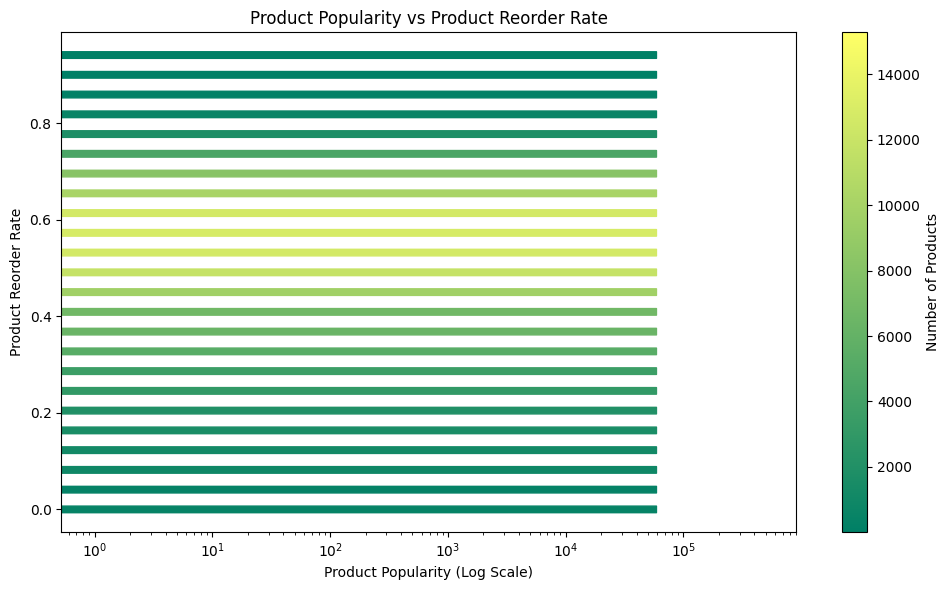

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

hb = plt.hexbin(
    df["product_popularity"],
    df["product_reorder_rate"],
    gridsize=40,
    cmap="summer",
    mincnt=1
)

plt.xscale("log")

plt.colorbar(hb, label="Number of Products")

plt.title("Product Popularity vs Product Reorder Rate")
plt.xlabel("Product Popularity (Log Scale)")
plt.ylabel("Product Reorder Rate")

plt.tight_layout()
plt.show()

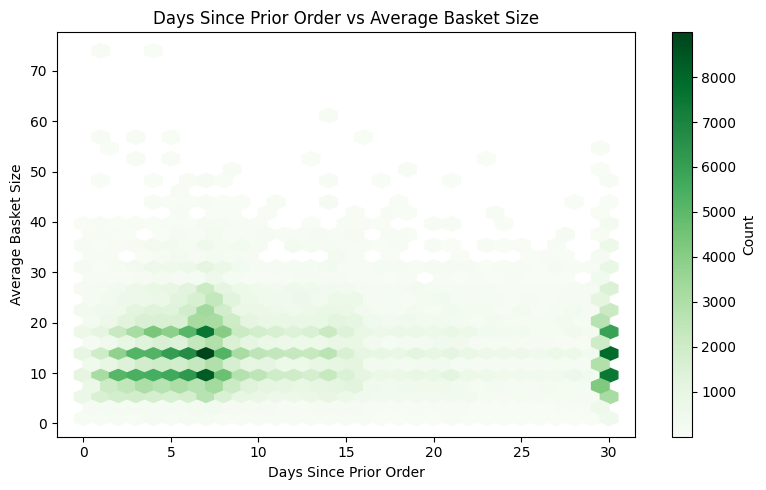

In [29]:
plt.figure(figsize=(8,5))

hb = plt.hexbin(
    df["days_since_prior_order"],
    df["average_basket_size"],
    gridsize=30,
    cmap="Greens",
    mincnt=1
)

plt.colorbar(hb, label="Count")

plt.title("Days Since Prior Order vs Average Basket Size")
plt.xlabel("Days Since Prior Order")
plt.ylabel("Average Basket Size")

plt.tight_layout()
plt.show()

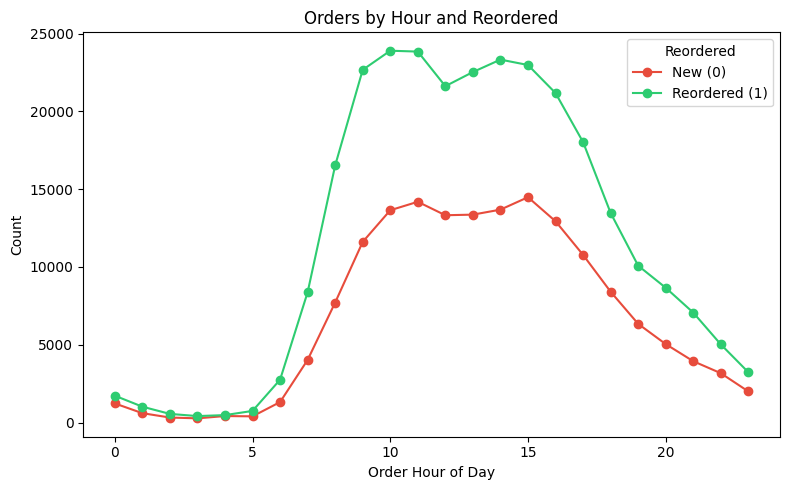

In [34]:
orders = df.drop_duplicates(subset=["order_id", "add_to_cart_order"])

hourly = orders.groupby(["order_hour_of_day", "reordered"]).size().reset_index(name="Count")

plt.figure(figsize=(8, 5))
for r in [0, 1]:
    subset = hourly[hourly["reordered"] == r]
    label = "New (0)" if r == 0 else "Reordered (1)"
    plt.plot(subset["order_hour_of_day"], subset["Count"], marker="o", color="#E74C3C" if r == 0 else "#2ECC71", label=label)

plt.title("Orders by Hour and Reordered")
plt.xlabel("Order Hour of Day")
plt.ylabel("Count")
plt.legend(title="Reordered")
plt.tight_layout()
plt.show()

<Axes: xlabel='order_hour_of_day', ylabel='order_dow'>

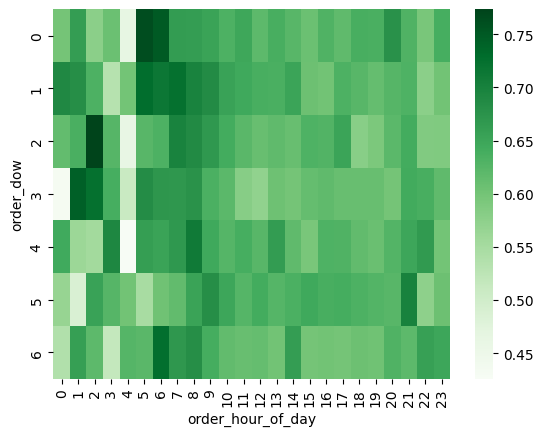

In [42]:
pivot = df.pivot_table(
    values="reordered",
    index="order_dow",
    columns="order_hour_of_day",
    aggfunc="mean"
)

sns.heatmap(pivot, cmap="Greens")

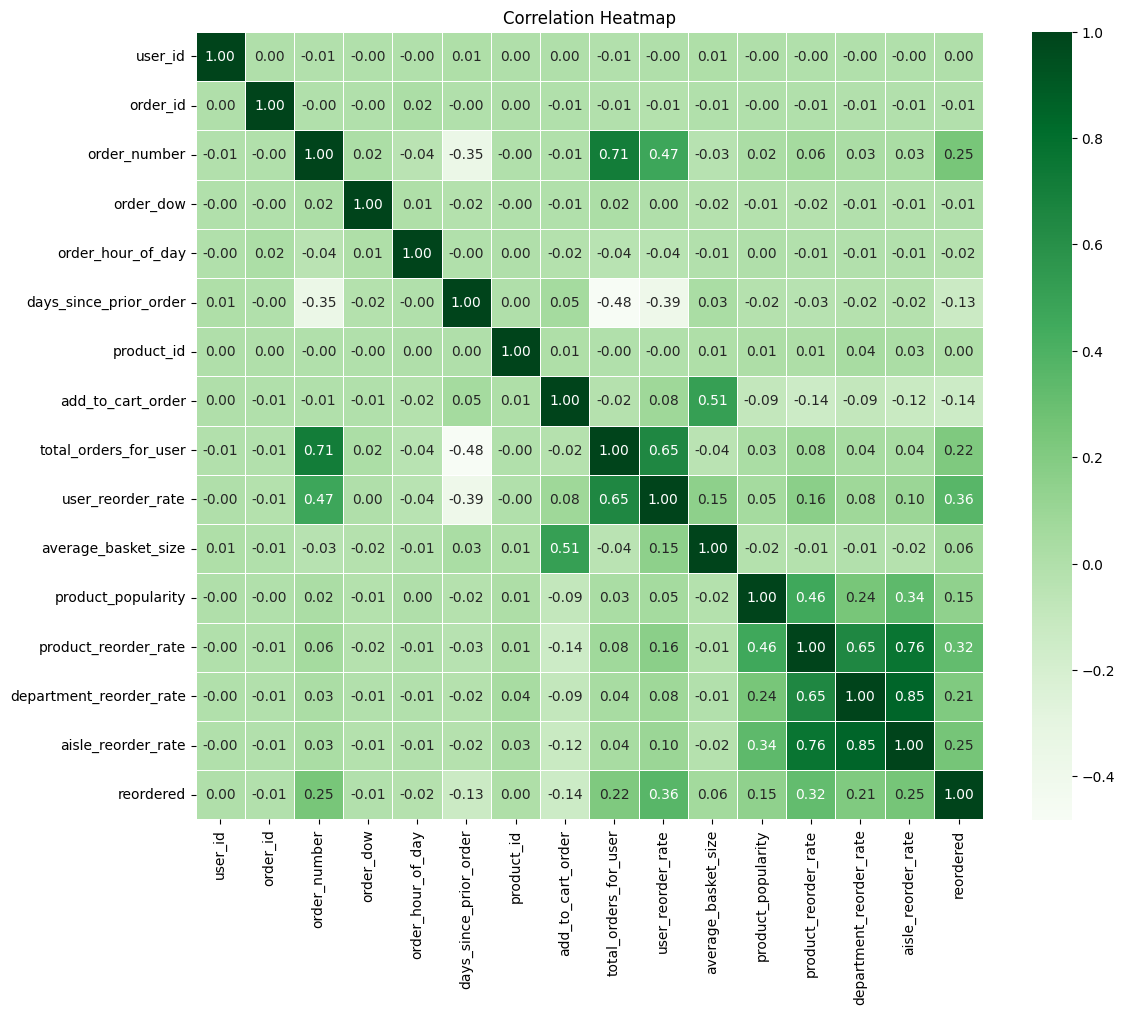

In [35]:
numeric_df = df.select_dtypes(include=["int64", "float64"])

plt.figure(figsize=(12, 10))
sns.heatmap(
    numeric_df.corr(),
    annot=True,
    fmt=".2f",
    cmap="Greens",
    linewidths=0.5,
    square=True,
)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

In [ ]:
from scipy.stats import chi2_contingency

def categorical_association(df, categorical_col, target="reordered"):
    # Contingency Table
    contingency_table = pd.crosstab(df[categorical_col], df[target])

    # Chi-Square Test
    chi2, p, dof, expected = chi2_contingency(contingency_table)

    # Cramer's V
    n = contingency_table.to_numpy().sum()
    min_dim = min(contingency_table.shape) - 1
    cramers_v = np.sqrt(chi2 / (n * min_dim))

    # Print Results
    print("=" * 55)
    print(f"Feature               : {categorical_col}")
    print(f"Chi-Square Statistic  : {chi2:.4f}")
    print(f"P-value               : {p:.6f}")
    print(f"Degrees of Freedom    : {dof}")
    print(f"Cramér's V            : {cramers_v:.4f}")

    # Statistical Significance
    if p < 0.05:
        print("Association           : Statistically Significant")
    else:
        print("Association           : Not Statistically Significant")

    # Effect Size Interpretation
    if cramers_v < 0.10:
        strength = "Negligible"
    elif cramers_v < 0.30:
        strength = "Weak"
    elif cramers_v < 0.50:
        strength = "Moderate"
    else:
        strength = "Strong"

    print(f"Effect Size           : {strength}")
    print("=" * 55)

In [40]:
categorical_columns = list(df.select_dtypes(include=["object", "category"]).columns)

categorical_columns.extend([
    "order_dow",
    "order_hour_of_day"
])

# Remove duplicates if any
categorical_columns = list(set(categorical_columns))

for col in categorical_columns:
    if col != "reordered":  # Skip the target column
        categorical_association(df, col)

Feature               : department
Chi-Square Statistic  : 19787.8218
P-value               : 0.000000
Degrees of Freedom    : 20
Cramér's V            : 0.2112
Association           : Statistically Significant
Effect Size           : Weak
Feature               : aisle
Chi-Square Statistic  : 27919.8212
P-value               : 0.000000
Degrees of Freedom    : 133
Cramér's V            : 0.2509
Association           : Statistically Significant
Effect Size           : Weak
Feature               : order_dow
Chi-Square Statistic  : 170.9030
P-value               : 0.000000
Degrees of Freedom    : 6
Cramér's V            : 0.0196
Association           : Statistically Significant
Effect Size           : Negligible
Feature               : product_name
Chi-Square Statistic  : 71723.7710
P-value               : 0.000000
Degrees of Freedom    : 27752
Cramér's V            : 0.4021
Association           : Statistically Significant
Effect Size           : Moderate
Feature               : order_hou

## Chi-Square Test & Cramér's V Analysis

To evaluate the association between categorical features and the target variable (`reordered`), a **Chi-Square Test of Independence** was performed. Since the dataset contains over **440,000 observations**, the **P-value** is expected to be extremely small even for weak relationships. Therefore, **Cramér's V** is used to measure the strength of the association.

### Results

| Feature | Cramér's V | Interpretation |
|----------|-----------:|----------------|
| Product Name | 0.402 | Moderate |
| Aisle | 0.251 | Weak |
| Department | 0.211 | Weak |
| Order Hour | 0.042 | Negligible |
| Order Day | 0.020 | Negligible |

### Observations

- **Product Name** shows the strongest association with the target. However, it has very high cardinality and represents the same information as `product_id`, so it will not be used as a model feature.
- **Aisle** has a stronger association with reorder behavior than **Department**, indicating that more specific product categories provide better predictive information.
- **Department** also demonstrates a meaningful relationship with the target, although weaker than Aisle.
- **Order Hour** and **Order Day** have negligible associations with the target, suggesting that purchase timing alone is not a strong predictor of product reordering.
- Due to the large sample size, the **P-values are statistically significant for all tested features**, but **Cramér's V** provides a more meaningful measure of practical significance.

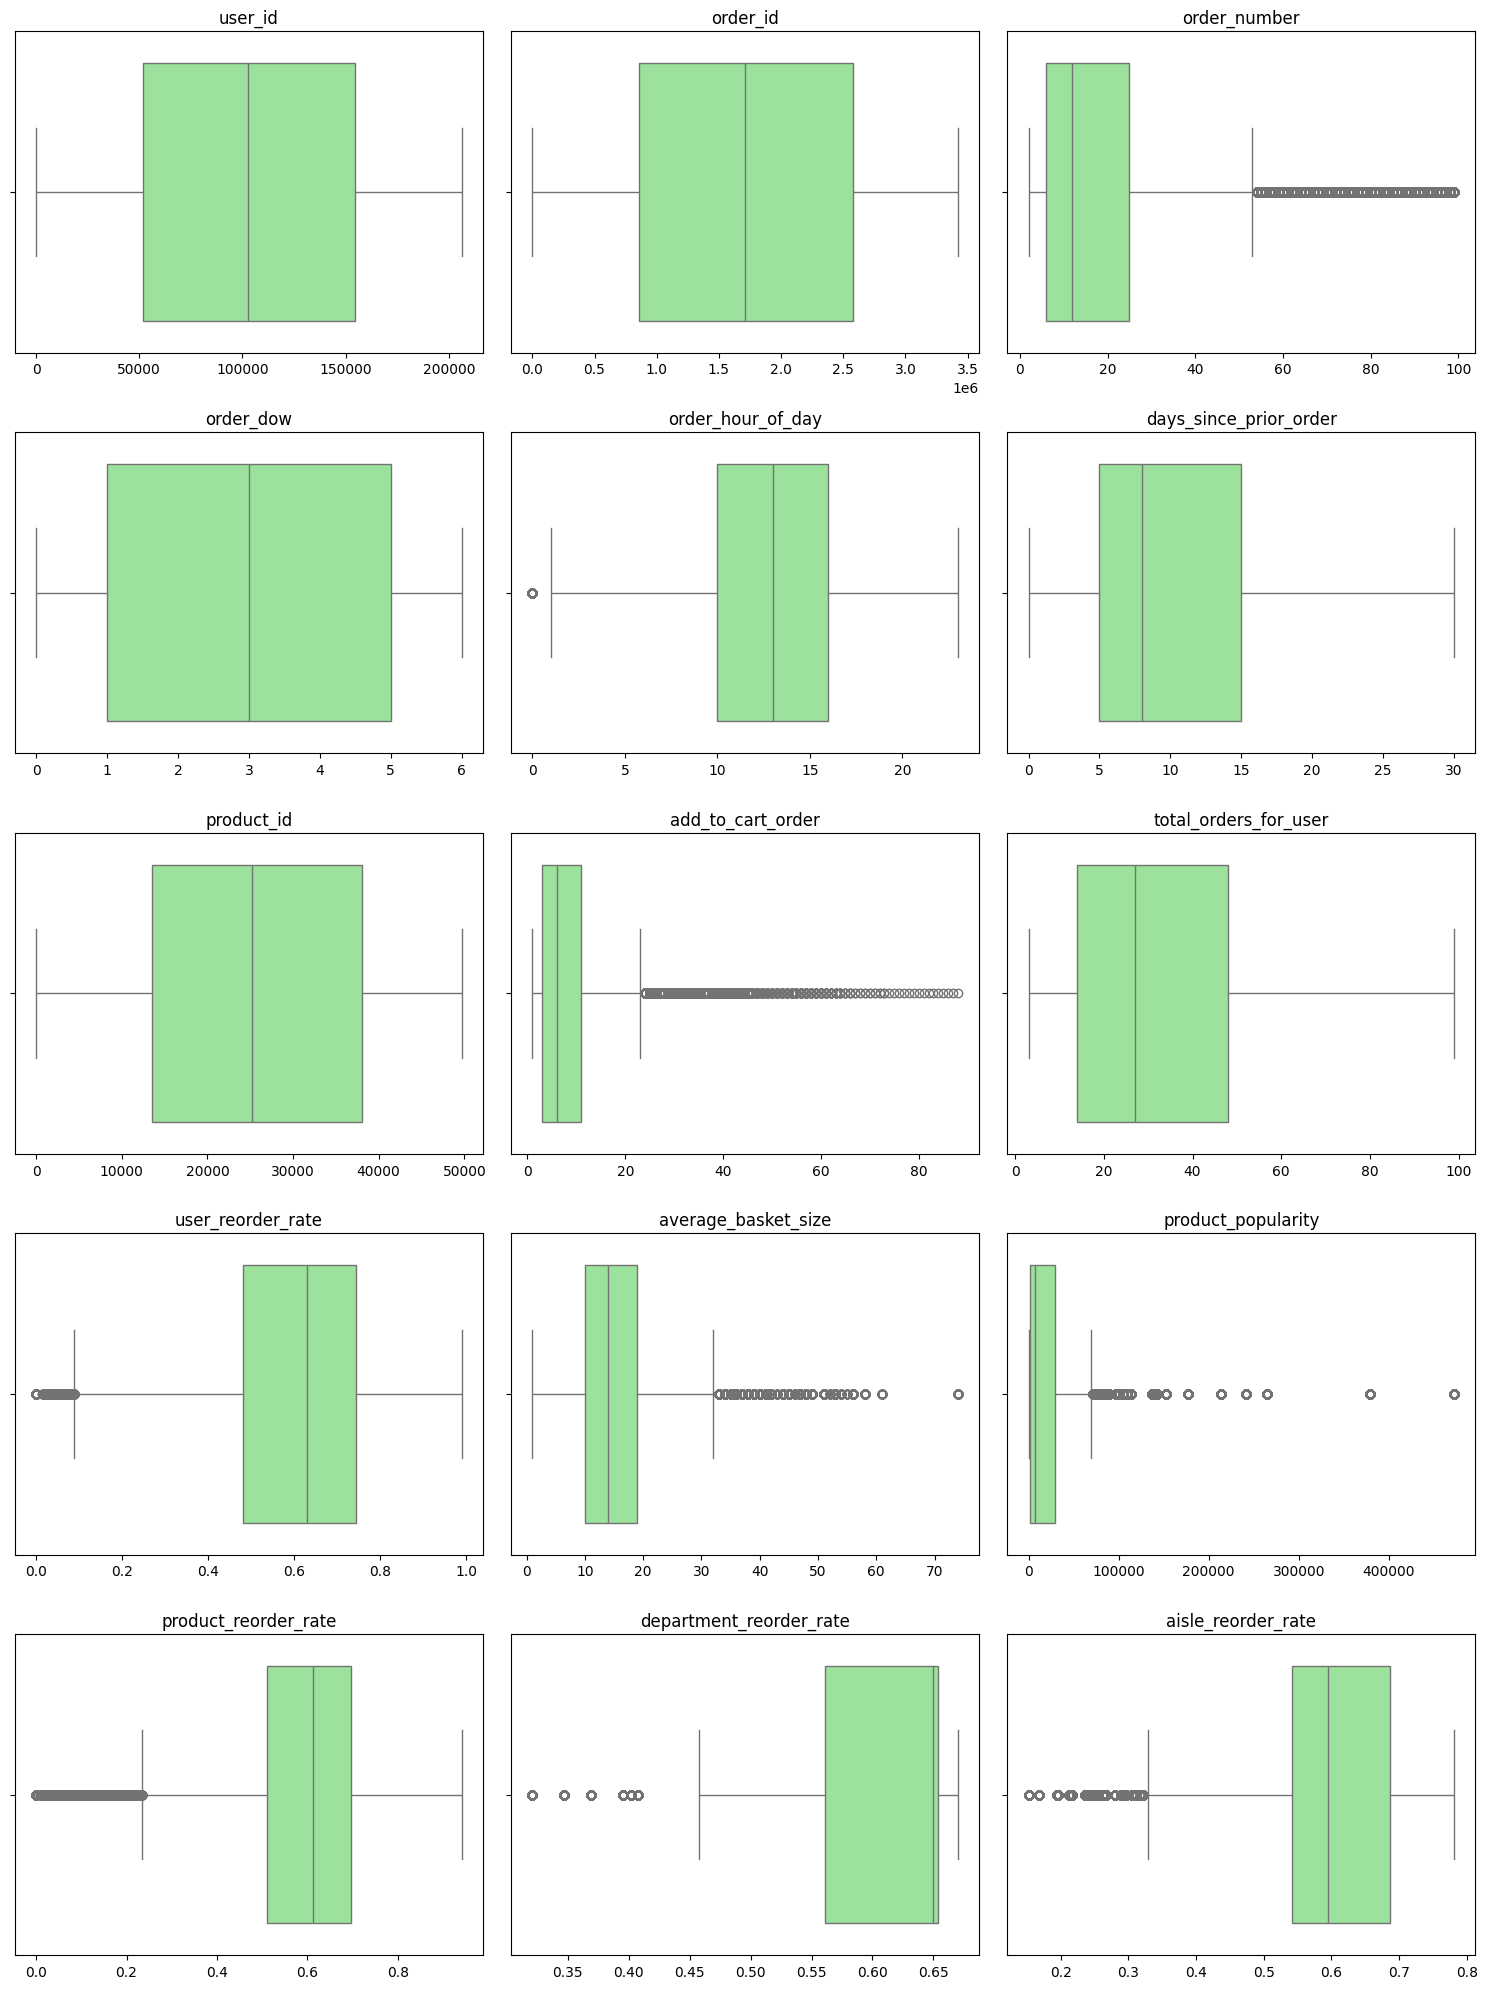

In [46]:
import math
numerical_columns = df.select_dtypes(include=["number"]).columns.drop("reordered")

n_cols = 3
n_rows = math.ceil(len(numerical_columns) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.flatten()

for ax, col in zip(axes, numerical_columns):
    sns.boxplot(
        x=df[col],
        ax=ax,
        color="lightgreen"
    )

    ax.set_title(col)
    ax.set_xlabel("")

# Remove empty subplots
for ax in axes[len(numerical_columns):]:
    fig.delaxes(ax)

plt.tight_layout()
plt.show()

## Outlier Analysis

Boxplots were used to inspect the numerical features for potential outliers.

Several variables, including `product_popularity`, `average_basket_size`, `order_number`, and `add_to_cart_order`, exhibit extreme values. However, these observations are consistent with the business context rather than data quality issues.

For example:

- Some products are significantly more popular than others.
- A small number of customers place many more orders than average.
- Some orders naturally contain a large number of products.

Therefore, these outliers were **retained** because they represent valid customer behavior and may provide valuable predictive information for the machine learning models.

In [48]:
X = df.drop(columns=[
    "reordered",      # Target
    "user_id",        # ID
    "order_id",       # ID
    "product_name"    # High cardinality + redundant with product_id
])

y = df["reordered"]

# Model Selection

Several machine learning algorithms are suitable for binary classification problems, including Logistic Regression, Random Forest, XGBoost, LightGBM, and CatBoost.

For this project, **XGBoost** and **CatBoost** were considered the most appropriate candidates because both are gradient boosting algorithms capable of modeling complex, non-linear relationships and feature interactions. They also perform well on structured tabular datasets such as the Instacart Market Basket Analysis dataset.

## Why CatBoost?

Although both models are strong choices, **CatBoost** was selected for the following reasons:

- The dataset contains multiple **categorical features** such as `department`, `aisle`, and `product_id`.
- CatBoost is specifically designed to handle categorical variables efficiently without relying on extensive manual feature engineering.
- It uses **Ordered Target Statistics**, which reduces the risk of target leakage when encoding categorical features.
- It naturally captures complex non-linear relationships and interactions between numerical and categorical variables.
- It is robust to outliers and requires minimal preprocessing compared to many other algorithms.
- CatBoost generally performs very well on tabular datasets with mixed numerical and categorical features, which closely matches the characteristics of this dataset.

## Why Not XGBoost?

XGBoost is also an excellent algorithm and is widely regarded as one of the best models for structured data. However, it requires categorical variables to be encoded before training. Since this dataset contains several categorical features with relatively high cardinality (especially `product_id`), additional encoding techniques would be required, increasing preprocessing complexity and the risk of introducing information leakage if not implemented carefully.

## Final Choice

Considering the nature of the dataset, the presence of categorical features, and the goal of minimizing preprocessing while maintaining strong predictive performance, **CatBoost** was selected as the primary machine learning model for this project.

# Spliting Data

In [51]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [53]:
categorical_features = [
    "product_id",
    "department",
    "aisle",
    "order_dow",
    "order_hour_of_day"
]

In [59]:
model = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.05,
    depth=6,
    loss_function="Logloss",
    eval_metric="AUC",
    random_seed=42,
    verbose=100,
    early_stopping_rounds=50
)
model.fit(
    X_train,
    y_train,
    cat_features=categorical_features
)

0:	total: 345ms	remaining: 5m 44s
100:	total: 38s	remaining: 5m 38s
200:	total: 1m 15s	remaining: 5m
300:	total: 1m 52s	remaining: 4m 21s
400:	total: 2m 29s	remaining: 3m 43s
500:	total: 3m 7s	remaining: 3m 6s
600:	total: 3m 44s	remaining: 2m 29s
700:	total: 4m 23s	remaining: 1m 52s
800:	total: 5m 1s	remaining: 1m 14s
900:	total: 5m 39s	remaining: 37.3s
999:	total: 6m 17s	remaining: 0us


CatBoostClassifier(depth=6, early_stopping_rounds=50, eval_metric='AUC', iterations=1000, learning_rate=0.05, loss_function='Logloss', random_seed=42, verbose=100)

In [60]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

In [61]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.72      0.59      0.65     32715
           1       0.78      0.87      0.82     55994

    accuracy                           0.76     88709
   macro avg       0.75      0.73      0.74     88709
weighted avg       0.76      0.76      0.76     88709



In [ ]:


cat_model = CatBoostClassifier(
    loss_function="Logloss",
    eval_metric="AUC",
    random_seed=42,
    verbose=0
)

param_dist = {
    "iterations": [500, 800, 1000, 1200],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "depth": [4, 5, 6, 7, 8],
    "l2_leaf_reg": [1, 3, 5, 7, 9],
    "bagging_temperature": [0, 1, 3, 5],
    "border_count": [32, 64, 128, 254]
}

random_search = RandomizedSearchCV(
    
    estimator=cat_model,
    param_distributions=param_dist,
    n_iter=10,
    scoring="roc_auc",
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

random_search.fit(
    X_train,
    y_train,
    cat_features=categorical_features
)

print("Best Parameters:")
print(random_search.best_params_)

print("\nBest ROC-AUC:")
print(random_search.best_score_)